### **Autor:** David Roca Tauste

---
---
# **ACTIVIDAD 4: ANÁLISIS DE SENTIMIENTOS EN TEXTO**
---
---

## ENTREGA 10: Busca en las web de establecimientos que conozcas o visites (o aunque no los visites algún restaurante o cervecería de tu zona) y seleccionas 10 reseñas de clientes (al menos 5 de ellas favorables y el resto hasta llegar a 10 desfavorables). Les das el mismo formato que el usado en las que te paso y las subes en el fichero "<3_primeras_letras_tu_nombre>_<3_primeras_letras_tus_apellidos>.txt" a una carpeta compartida en aules.
Añade también por el final tus reseñas al fichero compartido ‘reseñas_restaurantes.csv’ que será inicialmente una copia del anterior y que debería ir aumentando con las reseñas que vayamos añadiendo. Antes de comenzar el ejercicio, todos tus compañeros habrán hecho lo mismo, por tanto la cantidad de datos habrá aumentado un poco.

Ya las he añadido al fichero txt y al CSV.

a) Importar datos y eliminar la primera columna (puntuación).

In [27]:
import pandas as pd

# apartado a)
df = pd.read_csv('reseñas_restaurantes.csv', sep=";")
print(df.info())

del(df['puntuación']) # Borramos puntuaciones
datos = [tuple(x) for x in df.values] # Transformar una lista de tuplas

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61 entries, 0 to 60
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   puntuación   61 non-null     int64 
 1   comentario   61 non-null     object
 2   sentimiento  61 non-null     object
dtypes: int64(1), object(2)
memory usage: 1.6+ KB
None


b) Queremos normalizar los mensajes de texto. Vamos a pasar las letras a minúsculas, eliminar los signos de puntuación, eliminar las palabras con menos de 3 letras y eliminar las stop-words del castellano. Pasamos las palabras a su lema o forma raíz (lemmatización o stemización) para eliminar variantes. En vez de hacerlo a mano usando expresiones regulares, podemos emplear librerías de manipulación de texto:
- spacy: una librería de software para procesamiento de lenguajes naturales, reconocimiento de nombres de entidades, análisis de redes, visualización de datos, análisis, visual analysis, análisis de contenidos, enriching y anotación desarrollado por Matt Honnibal en Python.
- NLTK: El kit de herramientas de lenguaje natural es un conjunto de bibliotecas y programas para el procesamiento del lenguaje natural simbólico y estadísticos para Python. NLTK incluye demostraciones gráficas y datos de muestra.

In [28]:
import nltk
from tqdm import tqdm
from nltk.tokenize import word_tokenize  # Tokeniza palabras
from nltk.corpus import stopwords  # Stop-words, palabras comunes

# === Apartado b)
# Para instalar nltk puedes hacer: pip install nltk==3.9.1
# Si quieres elegir paquetes, corpus, datos individuales ejecuta interactiva:
# import nltk
# nltk.download()
# Y se abre pagina web donde eliges
nltk.download("punkt")  # Es un tokenizador de nltk en ingles y español
nltk.download("punkt_tab")  # Lo pide
nltk.download("stopwords")

spanish_sw = set(stopwords.words("spanish"))

from nltk.stem import PorterStemmer  # Stemmer para eliminar variedad

porter = PorterStemmer()


def normaliza(mensajes):
    """
    Preprocesa los datos de texto
    Entradas: mensajes con formato [(texto, etiqueta)]
    Salidas: mensajes con formato [(texto, label), (texto, label), ...]
    """
    for idx, msj in enumerate(tqdm(mensajes)):
        tokens = word_tokenize(msj[0].lower(), language="spanish")  # Paso a minusculas
        filtrado = [
            palabra
            for palabra in tokens
            if (len(palabra) > 2) and (palabra not in spanish_sw)
        ]
        stemmed = " ".join([porter.stem(p) for p in filtrado])
        mensajes[idx] = (stemmed, msj[1])
    return mensajes


X = normaliza(datos)  # Normalizamos el texto de los comentarios

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\davil\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\davil\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\davil\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
100%|██████████| 61/61 [00:00<00:00, 1089.68it/s]


c) Dividir los datos en el 80% para train y comprobar si hay un % adecuado de cada clase en train y en test.

In [29]:
from sklearn.model_selection import train_test_split

# === Apartado c)
y = [Y[1] for Y in X]
n_positivos = y.count("positivo")
n_total = len(y)
r_positivos = n_positivos / n_total
r_negativos = 1 - r_positivos

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

## ENTREGA 11: completa el siguiente código hasta conseguir salidas similares a las de las figuras que aparecen a continuación, pasa captura de la ejecución como esta:

In [30]:
print(f"\nReseñas en total: {n_total} - Positivos ({(100.0 * r_positivos):.4f}%)")

tamanyo_train = len(X_train)
tamanyo_test = len(X_test)

positivos_train = y_train.count("positivo")
positivos_test = y_test.count("positivo")

porcentaje_positivos_train = 100.0 * positivos_train / tamanyo_train
porcentaje_positivos_test = 100.0 * positivos_test / tamanyo_test

print(f"Reseñas para train: {tamanyo_train} - Positivos: {porcentaje_positivos_train}%")
print(f"Reseñas para test: {tamanyo_test} - Positivos: {porcentaje_positivos_test}%")


Reseñas en total: 61 - Positivos (63.9344%)
Reseñas para train: 48 - Positivos: 72.91666666666667%
Reseñas para test: 13 - Positivos: 30.76923076923077%


d) Crear la bolsa de palabras. Ahora crearemos un diccionario (no es un diccionario de Python) que contenga todas las diferentes palabras que aparecen en las reseñas de entrenamiento. Va a ser una colección de tuplas que contiene en la primera posición un booleano por cada palabra del diccionario indicando si la palabra aparece o no en la reseña y en la segunda posición la clase de la frase. Para hacerla creamos dos funciones que preparan los datos a como los necesita nltk:

In [31]:
# === Apartado d)
def palabras_diferentes(datos):
    """Devuelve una lista con todas las palabras únicas de las frases"""
    todas = []
    for texto, sentimiento in datos:
        todas.extend(nltk.word_tokenize(texto, language="spanish"))
    return list(set(todas))


diccionario = palabras_diferentes(X)  # Creamos el diccionario de palabras


def extrae_caracteristicas(texto):
    """
    Crea el conjunto de entrenamiento del clasificador
    1: Para cada palabra del diccionario
    3: Escribe {'contains(palabra)':True,...} si aparece palabra en texto
       Escribe {'contains(palabra)':False,...} si no aparece
    """
    palabras_del_texto = set(texto.split())
    caracteristicas = {}
    for palabra in diccionario:
        caracteristicas["contains(%s)" % palabra] = palabra in palabras_del_texto
    return caracteristicas


# Creamos las estructuras de datos para el clasificador con NLTK
X_train_nltk = nltk.classify.apply_features(extrae_caracteristicas, X_train)
X_test_nltk = nltk.classify.apply_features(extrae_caracteristicas, X_test)

e) Con el diccionario creado podemos usar cualquier clasificador. Vamos a crear y entrenar un naive Bayes, naive Bayes Multinomial, naive Bayes Bernouilli, Regresión logística y SVM (máquina de vector soporte).

In [32]:
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# === Apartado e)
print("Entrenando Naive Bayes")
nb = nltk.classify.NaiveBayesClassifier.train(X_train_nltk)
print("Entrenando Naive Bayes Multinomial")
nbm = nltk.classify.SklearnClassifier(MultinomialNB()).train(X_train_nltk)
print("Entrenando Bernoulli Naive Bayes")
nbb = nltk.classify.SklearnClassifier(BernoulliNB()).train(X_train_nltk)
print("Entrenando Regresion Logistica")
rl = nltk.classify.SklearnClassifier(
    LogisticRegression(solver="lbfgs", max_iter=1000)
).train(X_train_nltk)
print("Entrenando Support Vector Machine")
svm = nltk.classify.SklearnClassifier(SVC(kernel="linear")).train(X_train_nltk)
clasificadores = {
    "Naive Bayes": nb,
    "Naive Bayes Multinomial": nbm,
    "Naive Bayes Bernoulli": nbb,
    "Regresion Logistica": rl,
    "Support Vector Machine": svm,
}

Entrenando Naive Bayes
Entrenando Naive Bayes Multinomial
Entrenando Bernoulli Naive Bayes
Entrenando Regresion Logistica
Entrenando Support Vector Machine


f) Ahora vamos a medir el funcionamiento de todos ellos calculando sus métricas y vamos a presentarlas en forma tabular creando un DataFrame de Pandas para poder compararlas de manera sencilla.

In [33]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import warnings
warnings.filterwarnings("ignore")

# === Apartado f)
evaluacion = list()
for k, v in clasificadores.items():
    print(f"Evaluando Modelo: {k}")
    # Obtengo las predicciones
    predicciones = [v.classify(texto[0]) for texto in X_test_nltk]
    modelo = {}
    modelo["nombre"] = k
    modelo["accuracy"] = accuracy_score(y_true=y_test, y_pred=predicciones)
    modelo["precision"] = precision_score(
        y_true=y_test, y_pred=predicciones, average="weighted"
    )
    modelo["recall"] = recall_score(
        y_true=y_test, y_pred=predicciones, average="weighted"
    )
    modelo["f1"] = f1_score(y_true=y_test, y_pred=predicciones, average="weighted")
    evaluacion.append(modelo)

# Pasamos los resultados a un DataFrame para visualizarlos mejor
df = pd.DataFrame.from_dict(evaluacion)
df.set_index("nombre", inplace=True)
print(df)

Evaluando Modelo: Naive Bayes
Evaluando Modelo: Naive Bayes Multinomial
Evaluando Modelo: Naive Bayes Bernoulli
Evaluando Modelo: Regresion Logistica
Evaluando Modelo: Support Vector Machine
                         accuracy  precision    recall        f1
nombre                                                          
Naive Bayes              0.384615   0.641026  0.384615  0.288462
Naive Bayes Multinomial  0.461538   0.506410  0.461538  0.435718
Naive Bayes Bernoulli    0.384615   0.641026  0.384615  0.288462
Regresion Logistica      0.307692   0.094675  0.307692  0.144796
Support Vector Machine   0.307692   0.094675  0.307692  0.144796


## ENTREGA 12: Crea el programa y lo ejecutas y mira las métricas de los diferentes clasificadores. Pasa una captura de pantalla de los resultados obtenidos.
Se encuentra arriba.

## ENTREGA 13: Escribe una evaluación razonada de los resultados (cuál te quedarías, el motivo…).
Los resultados son muy malos, con un accuracy en todos menor del 50%. Si tuviese que elegir el mejor, elegiría el Naive Bayes Multinomial, debido a que tiene el accuracy, recall y f1 más altos. De todas maneras, no lo utilizaría este tampoco porque sigue siendo un modelo malo

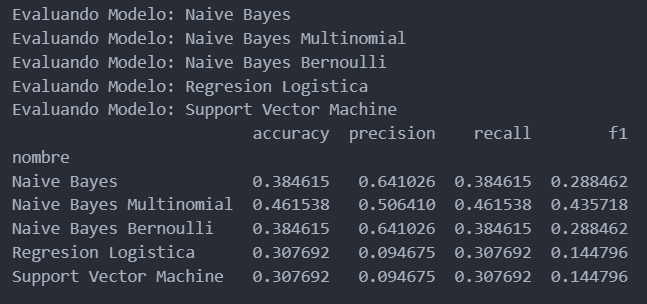

## ENTREGA 14: Repite el ejercicio pero ahora entrena los clasificadores con el fichero original, es decir, antes de que tú y tus compañeros hayan añadido nuevos datos (los datos originales serán las primeras 51 filas de datos). Muestra captura de pantalla de los resultados como en la entrega 17.
Se encuentra abajo.

---

In [34]:
import pandas as pd

# apartado a)
df = pd.read_csv('reseñas_restaurantes_original.csv', sep=";")
print(df.info())

del(df['puntuación']) # Borramos puntuaciones
datos = [tuple(x) for x in df.values] # Transformar una lista de tuplas

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   puntuación   51 non-null     int64 
 1   comentario   51 non-null     object
 2   sentimiento  51 non-null     object
dtypes: int64(1), object(2)
memory usage: 1.3+ KB
None


In [35]:
import nltk
from tqdm import tqdm
from nltk.tokenize import word_tokenize  # Tokeniza palabras
from nltk.corpus import stopwords  # Stop-words, palabras comunes

# === Apartado b)
# Para instalar nltk puedes hacer: pip install nltk==3.9.1
# Si quieres elegir paquetes, corpus, datos individuales ejecuta interactiva:
# import nltk
# nltk.download()
# Y se abre pagina web donde eliges
nltk.download("punkt")  # Es un tokenizador de nltk en ingles y español
nltk.download("punkt_tab")  # Lo pide
nltk.download("stopwords")

spanish_sw = set(stopwords.words("spanish"))

from nltk.stem import PorterStemmer  # Stemmer para eliminar variedad

porter = PorterStemmer()


def normaliza(mensajes):
    """
    Preprocesa los datos de texto
    Entradas: mensajes con formato [(texto, etiqueta)]
    Salidas: mensajes con formato [(texto, label), (texto, label), ...]
    """
    for idx, msj in enumerate(tqdm(mensajes)):
        tokens = word_tokenize(msj[0].lower(), language="spanish")  # Paso a minusculas
        filtrado = [
            palabra
            for palabra in tokens
            if (len(palabra) > 2) and (palabra not in spanish_sw)
        ]
        stemmed = " ".join([porter.stem(p) for p in filtrado])
        mensajes[idx] = (stemmed, msj[1])
    return mensajes


X = normaliza(datos)  # Normalizamos el texto de los comentarios

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\davil\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\davil\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\davil\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
100%|██████████| 51/51 [00:00<00:00, 1961.48it/s]


In [36]:
from sklearn.model_selection import train_test_split

# === Apartado c)
y = [Y[1] for Y in X]
n_positivos = y.count("positivo")
n_total = len(y)
r_positivos = n_positivos / n_total
r_negativos = 1 - r_positivos

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [37]:
print(f"\nReseñas en total: {n_total} - Positivos ({(100.0 * r_positivos):.4f}%)")

tamanyo_train = len(X_train)
tamanyo_test = len(X_test)

positivos_train = y_train.count("positivo")
positivos_test = y_test.count("positivo")

porcentaje_positivos_train = 100.0 * positivos_train / tamanyo_train
porcentaje_positivos_test = 100.0 * positivos_test / tamanyo_test

print(f"Reseñas para train: {tamanyo_train} - Positivos: {porcentaje_positivos_train}%")
print(f"Reseñas para test: {tamanyo_test} - Positivos: {porcentaje_positivos_test}%")


Reseñas en total: 51 - Positivos (66.6667%)
Reseñas para train: 40 - Positivos: 62.5%
Reseñas para test: 11 - Positivos: 81.81818181818181%


In [38]:
# === Apartado d)
def palabras_diferentes(datos):
    """Devuelve una lista con todas las palabras únicas de las frases"""
    todas = []
    for texto, sentimiento in datos:
        todas.extend(nltk.word_tokenize(texto, language="spanish"))
    return list(set(todas))


diccionario = palabras_diferentes(X)  # Creamos el diccionario de palabras


def extrae_caracteristicas(texto):
    """
    Crea el conjunto de entrenamiento del clasificador
    1: Para cada palabra del diccionario
    3: Escribe {'contains(palabra)':True,...} si aparece palabra en texto
       Escribe {'contains(palabra)':False,...} si no aparece
    """
    palabras_del_texto = set(texto.split())
    caracteristicas = {}
    for palabra in diccionario:
        caracteristicas["contains(%s)" % palabra] = palabra in palabras_del_texto
    return caracteristicas


# Creamos las estructuras de datos para el clasificador con NLTK
X_train_nltk = nltk.classify.apply_features(extrae_caracteristicas, X_train)
X_test_nltk = nltk.classify.apply_features(extrae_caracteristicas, X_test)

In [39]:
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# === Apartado e)
print("Entrenando Naive Bayes")
nb = nltk.classify.NaiveBayesClassifier.train(X_train_nltk)
print("Entrenando Naive Bayes Multinomial")
nbm = nltk.classify.SklearnClassifier(MultinomialNB()).train(X_train_nltk)
print("Entrenando Bernoulli Naive Bayes")
nbb = nltk.classify.SklearnClassifier(BernoulliNB()).train(X_train_nltk)
print("Entrenando Regresion Logistica")
rl = nltk.classify.SklearnClassifier(
    LogisticRegression(solver="lbfgs", max_iter=1000)
).train(X_train_nltk)
print("Entrenando Support Vector Machine")
svm = nltk.classify.SklearnClassifier(SVC(kernel="linear")).train(X_train_nltk)
clasificadores = {
    "Naive Bayes": nb,
    "Naive Bayes Multinomial": nbm,
    "Naive Bayes Bernoulli": nbb,
    "Regresion Logistica": rl,
    "Support Vector Machine": svm,
}

Entrenando Naive Bayes


Entrenando Naive Bayes Multinomial
Entrenando Bernoulli Naive Bayes
Entrenando Regresion Logistica
Entrenando Support Vector Machine


In [40]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import warnings
warnings.filterwarnings("ignore")

# === Apartado f)
evaluacion = list()
for k, v in clasificadores.items():
    print(f"Evaluando Modelo: {k}")
    # Obtengo las predicciones
    predicciones = [v.classify(texto[0]) for texto in X_test_nltk]
    modelo = {}
    modelo["nombre"] = k
    modelo["accuracy"] = accuracy_score(y_true=y_test, y_pred=predicciones)
    modelo["precision"] = precision_score(
        y_true=y_test, y_pred=predicciones, average="weighted"
    )
    modelo["recall"] = recall_score(
        y_true=y_test, y_pred=predicciones, average="weighted"
    )
    modelo["f1"] = f1_score(y_true=y_test, y_pred=predicciones, average="weighted")
    evaluacion.append(modelo)

# Pasamos los resultados a un DataFrame para visualizarlos mejor
df = pd.DataFrame.from_dict(evaluacion)
df.set_index("nombre", inplace=True)
print(df)

Evaluando Modelo: Naive Bayes
Evaluando Modelo: Naive Bayes Multinomial
Evaluando Modelo: Naive Bayes Bernoulli
Evaluando Modelo: Regresion Logistica
Evaluando Modelo: Support Vector Machine
                         accuracy  precision    recall        f1
nombre                                                          
Naive Bayes              0.909091   0.918182  0.909091  0.896332
Naive Bayes Multinomial  0.818182   0.818182  0.818182  0.818182
Naive Bayes Bernoulli    0.818182   0.669421  0.818182  0.736364
Regresion Logistica      0.818182   0.669421  0.818182  0.736364
Support Vector Machine   0.818182   0.669421  0.818182  0.736364


---
## ENTREGA 15: Valora si al añadir más datos se mejora la eficiencia de los clasificadores, a cuáles les afecta más el aumento en la cantidad de datos, etc.

Después de haber entrenado entrenado los modelos con los datos con mis reseñas y los datos originales, he llegado a la conclusión de que las métricas empeoran mucho al añadir reseñas. Creo que esto se debe a la diferencia entre las reseñas que yo he añadido y las que tenía el csv de serie.

El modelo más afectado por el incremento de datos ha sido el 'Naive Bayes' (para mal). Aquí están las métricas que lo demuestra:
- Antes de añadir datos:<br>
0.909091   0.918182  0.909091  0.896332<br><br>
- Después de añadir datos:<br>
0.384615   0.641026  0.384615  0.288462